In [99]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.ticker import FuncFormatter


In [100]:
# cost_def=pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="default")
# cost_defLCOE=pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="defaultLCOE")
# cost_inno=pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="innovation")
# cost_subsidy = pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="subsidyLCOE")
#She fucking askede for LCOE, then made me calculate how much CAPITAL COST REDUCTION will be reduced by PTC. THIS REQUIRES A LOT OF EXOGENOUS ASSUMPTIONS SO WE USE THE FILE BELOW.


In [124]:
cost_def=pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="default")
cost_defLCOE=pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="default")
cost_inno=pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="innovation")
cost_subsidy = pd.read_excel("Figure 4 costs_capital.xlsx", sheet_name="default and subsidy")

In [125]:
cost_def_2015=cost_inno[cost_inno['year']==2015] # innovation is a easier 
cost_def_2015_annual=cost_subsidy[cost_subsidy['year']==2015]
cost_def_2030=cost_defLCOE[cost_defLCOE['year']==2030]
cost_def_2050=cost_def[cost_def['year']==2050]
cost_inno_2050=cost_inno[cost_inno['year']==2050]
cost_sub_2030=cost_subsidy[cost_subsidy['year']==2030]

In [126]:
f4_2015=cost_def_2015[["solar", "wind", "BEV", "FCEV"]].reset_index(drop=True)
f4_2015_annual=cost_def_2015_annual[["solar", "wind", "BEV", "FCEV"]].reset_index(drop=True)

f4_2030=cost_def_2030[["solar", "wind", "BEV", "FCEV"]].reset_index(drop=True)
f4_2030_subsidy=cost_sub_2030[["solar", "wind", "BEV", "FCEV"]].reset_index(drop=True)
f4_2030

,solar,wind,BEV,FCEV
0,210,253,0.2243,0.261


In [127]:
f4_2030_subsidy

,solar,wind,BEV,FCEV
0,6.65338,6.580261,0.189458,0.226158


In [128]:
f4_change = (f4_2030 - f4_2015) / f4_2015
f4_change_subsidy = (f4_2030_subsidy - f4_2015_annual) / f4_2015_annual
f4_change

,solar,wind,BEV,FCEV
0,-0.62963,-0.439024,-0.159295,-0.264789


In [129]:
f4_change_subsidy

,solar,wind,BEV,FCEV
0,-0.909736,-0.887766,-0.289889,-0.362936


In [130]:
#same for f5.
f5_2015=cost_def_2015[["solar", "wind", "BEV", "FCEV","BECCS","DAC"]].reset_index(drop=True)
f5_2050=cost_def_2050[["solar", "wind", "BEV", "FCEV","BECCS","DAC"]].reset_index(drop=True)
f5_2050_subsidy=cost_inno_2050[["solar", "wind", "BEV", "FCEV","BECCS","DAC"]].reset_index(drop=True)
f5_change = (f5_2050 - f5_2015) / f5_2015
f5_change_subsidy = (f5_2050_subsidy - f5_2015) / f5_2015
f5_change

,solar,wind,BEV,FCEV,BECCS,DAC
0,-0.724868,-0.576497,-0.159295,-0.319155,-0.312686,-0.399866


In [131]:
f4_change

,solar,wind,BEV,FCEV
0,-0.62963,-0.439024,-0.159295,-0.264789


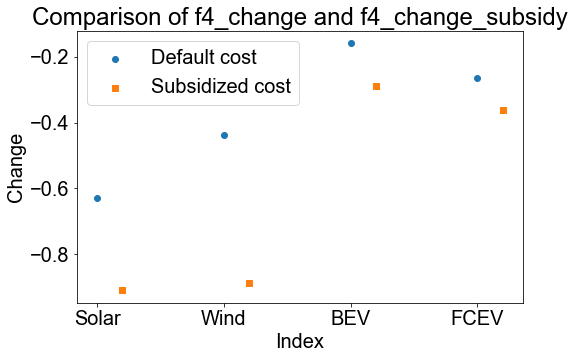

In [132]:
# 生成 x 轴的坐标（从 1 开始）
x = [1,2,3,4]
y = [1.2, 2.2, 3.2, 4.2]


# 画图
plt.figure(figsize=(8, 5))
plt.scatter(x, f4_change.values.flatten(), marker='o', label='Default cost')
plt.scatter(y, f4_change_subsidy.values.flatten(), marker='s', label='Subsidized cost')

# 添加标签和标题
plt.xlabel('Index')
plt.ylabel('Change')
plt.title('Comparison of f4_change and f4_change_subsidy')
# 添加 x 轴标签
plt.xticks(x, ["Solar", "Wind", "BEV", "FCEV"])  # 正确的方式
plt.legend()
# plt.grid(True)

# 显示图表
plt.show()

In [133]:
#1 sectoral emissions 2015 and 2030
#Sectoral

# calculation
Sec_stick=pd.read_csv("202502_CO2_sector_stick_20240822_80p.csv")
Sec_2030_nl=pd.read_csv("202502_CO2_sector_crt2030_80p_nl_202502.csv")
Sec_2030_l=pd.read_csv("202502_CO2_sector_crt2030_80p_l_202502.csv")
Sec_2040_nl=pd.read_csv("202502_CO2_sector_crt2040_80p_nl_202502.csv")
Sec_2040_l=pd.read_csv("202502_CO2_sector_crt2040_80p_l_202502.csv")
# Sec_2030_nl_trump=pd.read_csv("CO2_sector_crt2030_80p_nl_0821_trump.csv")
# Sec_2030_l_trump=pd.read_csv("CO2_sector_crt2030_80p_l_0821_trump.csv")
Sec_2040_nl_trump=pd.read_csv("202502_CO2_sector_crt2040_80p_nl_202502_trump.csv")
Sec_2050 = pd.read_csv("2025_CO2_sector_all_in_xinyuan.csv")
# Sec_2040_l_trump=pd.read_csv("CO2_sector_crt2040_80p_l_0821_trump.csv")
# Sec_CS['Sector_B']=[]
def sectoralallocation(x):
    
    SEC=[]
    for sec in x['sector']:

        if sec in ["backup_electricity" ,"N fertilizer", "cement" ,     "H2 central production" ,    "H2 wholesale dispensing" ,  "other industrial energy use" , "other industrial feedstocks" , "process heat cement"] :
            SEC.append("industry")
        elif sec in ["csp_backup", "base load generation",  "intermediate generation",  "peak generation","subpeak generation"]:
            SEC.append("power")
        elif sec in ["comm cooking" , "comm cooling" , "comm heating", "comm hot water", "comm other", "resid clothes dryers", "resid cooking" ,
                     "resid heating","resid hot water" , "resid other"]:
            SEC.append("residential commercial")
        elif "trn_" in sec:
#         elif sec.contains("trn_"):
            SEC.append("transportation")
        elif sec in ['biomass liquids', 'regional biomassOil' , "gas pipeline" ,"gas processing" , "oil refining" ,'regional corn for ethanol',"coal to liquids" ,"gas to liquids" , 'regional biomass','delivered biomass' ]:
            SEC.append("refinery")#highlight regional biomass(Oil)
        elif sec in ["airCO2","process heat dac"]:
            SEC.append("DAC")


        else:
            SEC.append("???")
            print(sec)
            continue
    x['Sector_B']=SEC

#     Allsecs=["agriculture","industry","power","residential commercial","transportation","DAC"]
    Allsecs=["industry","power","residential commercial","transportation","refinery","DAC"]


    SectoralE = []
    for sec in Allsecs:
        sector_e = []
        e2005 = x.loc[(x['Sector_B'] == sec) & (x['Year'] == 2005),'co2.emiss'].sum()
        e2015 = x.loc[(x['Sector_B'] == sec) & (x['Year'] == 2015),'co2.emiss'].sum()
        e2020 = x.loc[(x['Sector_B'] == sec) & (x['Year'] == 2020),'co2.emiss'].sum()
        e2025 = x.loc[(x['Sector_B'] == sec) & (x['Year'] == 2025),'co2.emiss'].sum()
    #         e2025 = Sec_60.loc[Sec_60['Sector_B'] == sec, 'i2025'].sum()
        e2030 = x.loc[(x['Sector_B'] == sec)& (x['Year'] == 2030),'co2.emiss'].sum()
        e2035 = x.loc[(x['Sector_B'] == sec)& (x['Year'] == 2035),'co2.emiss'].sum()
        e2040 = x.loc[(x['Sector_B'] == sec)& (x['Year'] == 2040),'co2.emiss'].sum()
    #         e2040 = Sec_60.loc[Sec_60['Sector_B'] == sec, 'i2040'].sum()
    #         e2045 = Sec_60.loc[Sec_60['Sector_B'] == sec, 'i2045'].sum()
        e2050 = x.loc[(x['Sector_B'] == sec)& (x['Year'] == 2050),'co2.emiss'].sum()
        e2045 = x.loc[(x['Sector_B'] == sec)& (x['Year'] == 2045),'co2.emiss'].sum()
        sector_e.append(e2005)
        sector_e.append(e2015)
        sector_e.append(e2020)
        sector_e.append(e2025)
        sector_e.append(e2030)
        sector_e.append(e2035)
        
    #         sector_e.append(e2040)
    #         sector_e.append(e2045)
        sector_e.append(e2040)
        sector_e.append(e2045)
        sector_e.append(e2050)
        
        SectoralE.append(sector_e)

        # print(SectoralE)
    row_names = Allsecs
    # col_names = ['2025', '2030', '2035', '2040', '2045', '2050']
    col_names = ['2005','2015', '2020','2025','2030','2035', '2040','2045','2050']
    SectoralE_df = pd.DataFrame(SectoralE, index=row_names, columns=col_names)
        # 定义一个比例
    scale = 44/12

        # 将 DataFrame 中的所有数字乘以比例
    SectoralE_df = SectoralE_df.applymap(lambda x: x * scale if isinstance(x, (int, float)) else x)
#     print(SectoralE_df)



    return(SectoralE_df)



# 创建数据和列名列表
# all_files = [Sec_2040_l, Sec_2030_l,Sec_2040_nl,Sec_2030_nl,  Sec_stick]
# all_names = ['Carrot_LateStick_Innovation','Carrot_EarlyStick_Innovation','Carrot_LateStick',   'Carrot_EarlyStick', 'Stick-only']

all_files = [Sec_stick, Sec_2030_nl, Sec_2040_nl,Sec_2030_l, Sec_2040_l,
             #Sec_2030_nl_trump, 
             Sec_2040_nl_trump, Sec_2050#,Sec_2030_l_trump, Sec_2040_l_trump
            ]
all_names = ['Stick-only','Carrot_EarlyStick', 'Carrot_LateStick', 'Carrot_EarlyStick_Innovation','Carrot_LateStick_Innovation',
            #'Carrot_EarlyStick, Trump', 
             'Carrot_LateStick, Trump', "Carrot only"#, 'Carrot_EarlyStick_Innovation, Trump','Carrot_LateStick_Innovation, Trump'
            ]

# 使用数据和列名创建DataFrame
sec2015 = pd.DataFrame(columns=all_names)
sec2020 = pd.DataFrame(columns=all_names)
sec2025 = pd.DataFrame(columns=all_names)
sec2030 = pd.DataFrame(columns=all_names)

sec2035 = pd.DataFrame(columns=all_names)
sec2050 = pd.DataFrame(columns=all_names)

sec2040 = pd.DataFrame(columns=all_names)
sec2045 = pd.DataFrame(columns=all_names)

# print(sec2015)
# print(sec2035)
# print(sec2050)


for i in range(len(all_files)):
    file=all_files[i]
#     print(file)
    
    name=all_names[i]
#     print(type(name))
    sec2015[name]=sectoralallocation(file)['2015']
    sec2020[name]=sectoralallocation(file)['2020']
    sec2025[name]=sectoralallocation(file)['2025']
    sec2030[name]=sectoralallocation(file)['2030']
    sec2035[name]=sectoralallocation(file)['2035']
    sec2050[name]=sectoralallocation(file)['2050']
    sec2040[name]=sectoralallocation(file)['2040']
    sec2045[name]=sectoralallocation(file)['2045']

# file=Sec_ref
# print(type(file))
# #     name=all_names[i]
# #     print(type(name))
# sec2015[name]=sectoralallocation(file)['2015']
# sec2035[name]=sectoralallocation(file)['2035']
# sec2050[name]=sectoralallocation(file)['2050']
# sec2040[name]=sectoralallocation(file)['2040']

#合成一个
Sec15v=sec2015.transpose()
Sec20v=sec2020.transpose()
Sec25v=sec2025.transpose()
Sec30v=sec2030.transpose()
Sec35v=sec2035.transpose()
Sec40v=sec2040.transpose()
Sec45v=sec2045.transpose()
Sec50v=sec2050.transpose()

Sec15v['year']='i2015'
Sec20v['year']='i2020'
Sec25v['year']='i2025'
Sec30v['year']='i2030'
Sec35v['year']='i2035'
Sec40v['year']='i2040'
Sec45v['year']='i2045'
Sec50v['year']='i2050'



Sec15v2=Sec15v.iloc[[0]]
combined_df = pd.concat([Sec15v, Sec20v, Sec25v, Sec30v, Sec35v, Sec40v, Sec45v, Sec50v])

#add agricaultural things here
luc=pd.read_excel("CO2_LUC_80p.xlsx", sheet_name="CO2")

luc2=luc.set_index('scenarios')
luc3 = luc2.drop(columns=['E2005','E2010'])
luc4=luc3.T
luc4.reindex()
luc2015 = luc4.loc['E2015']
luc2030 = luc4.loc['E2030']
luc2035 = luc4.loc['E2035']
luc2050 = luc4.loc['E2050']

combined_df4 = combined_df.copy()
row2015_2=combined_df4.loc[(combined_df4.index == 'Stick-only') & (combined_df4['year'].isin(['i2015']))]

row2035_2 = combined_df4.loc[(combined_df4.index.isin(['Stick-only','Carrot_EarlyStick', 'Carrot_LateStick',  'Carrot_EarlyStick, Trump',
                                                       'Carrot_LateStick, Trump',"Carrot only"#, 
#                                                            'Carrot_EarlyStick_Innovation', 'Carrot_LateStick_Innovation'
                                                    ])) & 
                                 (combined_df4['year'].isin(['i2035']))]

row2030_2 = combined_df4.loc[(combined_df4.index.isin(['Stick-only','Carrot_EarlyStick', 
                                                       'Carrot_LateStick, Trump'#, 
#                                                        'Carrot_LateStick', 
#                                                            'Carrot_EarlyStick_Innovation', 'Carrot_LateStick_Innovation'
                                                    ])) & 
                                 (combined_df4['year'].isin(['i2030']))]


row2050_2 = combined_df4.loc[(combined_df4.index.isin(['Stick-only','Carrot_EarlyStick', 'Carrot_LateStick', 
                                                           'Carrot_EarlyStick_Innovation', 'Carrot_LateStick_Innovation',
                                                      #'Carrot_EarlyStick, Trump', 
                                                       'Carrot_LateStick, Trump',"Carrot only"#, 'Carrot_EarlyStick_Innovation, Trump','Carrot_LateStick_Innovation, Trump'
            
                                                      ])) & 
                                 (combined_df4['year'].isin(['i2050']))]
row2050_2

row2015_2['land use']=luc2015[1]

row2030_2['land use'] = luc2035[[0,1,2]]

row2035_2['land use'] = luc2035[[0,1]]
row2050_2['land use'] = luc2050
row2035_2

# 定义自定义 colormap 的颜色列表
colors4 = [#'#3cb44b',green for land use
    '#3d5a80',#dark blue, 
           "#90653A",#power换棕色
          
           
          '#98c1d9',# light blue, residential commercial
    
          #'#e0fbfc',#residential commercial换浅蓝色
          '#f0c648',
           '#9a9a9a',
          '#293241',
    '#00a86b'#this is for beccs
          ]

# 创建自定义 colormap 对象
Huilin4 = ListedColormap(colors4, name='my_colormap')



C:\Users\Huilin\AppData\Local\Temp\ipykernel_26452\3285150388.py:211: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2015_2['land use']=luc2015[1]
C:\Users\Huilin\AppData\Local\Temp\ipykernel_26452\3285150388.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  row2030_2['land use'] = luc2035[[0,1,2]]
C:\Users\Huilin\AppData\Local\Temp\ipykernel_26452\3285150388.py:215: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [134]:
row2030_2

,industry,power,residential commercial,transportation,refinery,DAC,year,land use
Stick-only,662.024909,669.791239,396.817977,1434.862379,88.572718,-1.007008,i2030,-92.364756
Carrot_EarlyStick,761.232825,756.553780,392.903233,1474.237732,159.497227,-1.298126,i2030,-97.153993
"Carrot_LateStick, Trump",759.276597,1204.218181,417.694483,1477.265735,161.032045,-1.634037,i2030,NaN


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 720x864 with 0 Axes>

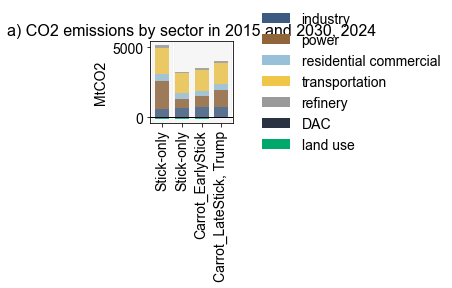

In [135]:
#plotting code trial
# 设置全局字体为Arial
ax3 = plt.figure(figsize=(10, 12))

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 14


all_df_secem = pd.concat([row2015_2, row2030_2])

# all_df_secem = pd.concat([row2015_2, row2030_2])




all_df_secem.plot(kind='bar', stacked=True,  cmap=Huilin4, width=0.7)

# 调整第二个柱形的位置
bar_width = 0.8  # 柱形的默认宽度
bar_spacing = 0.2  # 柱形之间的间距



# ax3.set_ylim(-4000, 7000)
plt.ylabel("MtCO2")


# 添加灰色背景
plt.axvspan(-0.5, 0.5, color='#D3D3D3', alpha=0.2)  # 第一个bar的背景
plt.axvspan(0.6, 3.5, color='#D3D3D3', alpha=0.2)  # 第2~4个bar的背景

plt.axhline(y=0, color='black', linewidth=1)

# 在第一个柱状图上添加文本
ax3.text(0, 6000, '2015', fontsize=14, ha='center', va='center', color='black', fontweight='bold')
ax3.text(1.5, 6000, '2030', fontsize=14, ha='center', va='center', color='black', fontweight='bold')
# ax3.text(5, 6000, '2050', fontsize=14, ha='center', va='center', color='black', fontweight='bold')
ax3.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False,prop={'family': 'Arial', 'size': 14},ncol=1)


plt.title("a) CO2 emissions by sector in 2015 and 2030, 2024", fontsize = 16)
plt.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=False,prop={'family': 'Arial', 'size': 14},ncol=1)
# plt.savefig("emissions 3 in 1_20240610.svg", transparent = True)
plt.tight_layout()
plt.show()

In [136]:
# panel 2 - power deployment

Gens=pd.read_excel("power_80p_202502.xlsx", sheet_name = "stick").iloc[:,:22]
Gen2030nl=pd.read_excel("power_80p_202502.xlsx", sheet_name = "crt2030_nl").iloc[:,:22]
Gen2030l=pd.read_excel("power_80p_202502.xlsx", sheet_name = "crt2030_l").iloc[:,:22]
Gen2040nl=pd.read_excel("power_80p_202502.xlsx", sheet_name = "crt2040_nl").iloc[:,:22]
Gen2040l=pd.read_excel("power_80p_202502.xlsx", sheet_name = "crt2040_l").iloc[:,:22]

# Gen2030nl_trump=pd.read_excel("power_80p_0821_trump.xlsx", sheet_name = "2030nl_trump").iloc[:,:22]
# Gen2030l_trump=pd.read_excel("power_80p_0821_trump.xlsx", sheet_name = "2030l_trump").iloc[:,:22]
Gen2040nl_trump=pd.read_excel("power_80p_202502.xlsx", sheet_name = "2040nl_trump").iloc[:,:22]
# Gen2040l_trump=pd.read_excel("power_80p_0821_trump.xlsx", sheet_name = "2040l_trump").iloc[:,:22]


Gens = Gens[Gens['Sub2'].notna()]
Gen2030nl = Gen2030nl[Gen2030nl['Sub2'].notna()]
Gen2030l = Gen2030l[Gen2030l['Sub2'].notna()]
Gen2040nl = Gen2040nl[Gen2040nl['Sub2'].notna()]
Gen2040l = Gen2040l[Gen2040l['Sub2'].notna()]

# Gen2030nl_trump = Gen2030nl_trump[Gen2030nl_trump['Sub2'].notna()]
# Gen2030l_trump = Gen2030l_trump[Gen2030l_trump['Sub2'].notna()]
Gen2040nl_trump = Gen2040nl_trump[Gen2040nl_trump['Sub2'].notna()]
# Gen2040l_trump = Gen2040l_trump[Gen2040l_trump['Sub2'].notna()]

desired_order = ['fossil w/o CCS',
                 'wind','solar','others','biomass w/o CCS',
                 'fossil w/ CCS','biomass w/ CCS']
# Gen_plot=Gen[['i2015','i2035','i2050']]
def output(Gen):
    Gen_tech=Gen["Sub2"]
    current_new_tech=[]
    for i in range(len(Gen_tech)):
        tech = Gen_tech.iloc[i]
        if "CCS" in tech:
            if "biomass" in tech:
                current_new_tech.append("biomass w/ CCS")
            else:
                current_new_tech.append("fossil w/ CCS")

        elif "biomass" in tech:
            current_new_tech.append("biomass w/o CCS")
        elif "coal" in tech:
            current_new_tech.append("fossil w/o CCS")
        elif "gas" in tech:
            current_new_tech.append("fossil w/o CCS")
        elif "liquids" in tech:
            current_new_tech.append("fossil w/o CCS")
        elif "PV" in tech:
            current_new_tech.append("solar")
        elif "rooftop" in tech:
            current_new_tech.append("solar")
        elif "CSP" in tech:
            current_new_tech.append("solar")
        elif "wind" in tech:
            current_new_tech.append("wind")

        else:
            current_new_tech.append("others")#here it's nuclear, geothermal, and hydro
    #         print("not included_noCCS", tech)

    #         Gen_tech.extend(current_new_tech)  # Extend the new_tech list with the current_new_tech list

    Gen['broad_tech'] = current_new_tech


    Gen.set_index('broad_tech', inplace=True)


    GEN = Gen.groupby('broad_tech').sum()
    return(GEN)

G_s=output(Gens)
G_2030nl=output(Gen2030nl)
G_2030l=output(Gen2030l)
G_2040nl=output(Gen2040nl)
G_2040l=output(Gen2040l)
# G_2030nl_trump=output(Gen2030nl_trump)
# G_2030l_trump=output(Gen2030l_trump)
G_2040nl_trump=output(Gen2040nl_trump)
# G_2040l_trump=output(Gen2040l_trump)

G_2030nl.reindex(desired_order)
G_2030l.reindex(desired_order)
G_2040nl.reindex(desired_order)
G_2040l.reindex(desired_order)

# G_2030nl_trump.reindex(desired_order)
# G_2030l_trump.reindex(desired_order)
G_2040nl_trump.reindex(desired_order)
# G_2040l_trump.reindex(desired_order)

G_s.reindex(desired_order)

G_s['scenario']='Stick-only'
G_2030nl['scenario']='Carrot_EarlyStick'
G_2040nl['scenario']='Carrot_LateStick'
G_2030l['scenario']='Carrot_EarlyStick_Innovation'
G_2040l['scenario']='Carrot_LateStick_Innovation'

# G_2030nl_trump['scenario']='Carrot_EarlyStick, Trump'
G_2040nl_trump['scenario']='Carrot_LateStick, Trump'
# G_2030l_trump['scenario']='Carrot_EarlyStick_Innovation, Trump'
# G_2040l_trump['scenario']='Carrot_LateStick_Innovation, Trump'

all_df=pd.concat([G_s, G_2030nl, G_2030l, G_2040nl, 
#                   G_2030nl_trump, G_2030l_trump, 
                  G_2040nl_trump, 
#                   , G_2040l
                 ], axis=0)
all_df
combined_df3 = all_df.copy()#.transpose()
combined_df3.reset_index(inplace=True)
combined_df3.rename(columns={'index': 'tech'}, inplace=True)

# combined_df3.reindex()
combined_df4 = combined_df3.pivot(index='scenario', columns='broad_tech', values='i2015')
# combined_df4

combined_df5 = combined_df3.pivot(index='scenario', columns='broad_tech', values='i2050')
# combined_df5

r50 = combined_df3[['i2050', 'scenario','broad_tech']]
# v2: only showing limited scenarios for r50, change this @Huilin
r50 = r50[r50['scenario'].isin(['Stick-only', 'Carrot_EarlyStick','Carrot_EarlyStick_Innovation','Carrot_LateStick'
                               ,
                                   'Carrot_LateStick, Trump'])]

r50 = r50.sort_values(by='broad_tech', key=lambda x: pd.Categorical(x, categories=desired_order, ordered=True))
r50 = r50.pivot(index = "scenario", columns = "broad_tech", values = "i2050")

# combined_df3=all_df.copy()
r2015 = combined_df3[['i2015', 'scenario','broad_tech']]
r15 = r2015[r2015['scenario'].isin(['Stick-only', '2030nl'])]
r15 = r15.sort_values(by='broad_tech', key=lambda x: pd.Categorical(x, categories=desired_order, ordered=True))
# r15.set_index('broad_tech', inplace=True)
# print(row2015)

r2035 = combined_df3[['i2035', 'scenario','broad_tech']]
r35 = r2035[r2035['scenario'].isin(['Stick-only', 'Carrot_EarlyStick','Carrot_EarlyStick_Innovation','Carrot_LateStick'
                               ,'Carrot_LateStick, Trump'])]
r35 = r35.sort_values(by='broad_tech', key=lambda x: pd.Categorical(x, categories=desired_order, ordered=True))
# r35.set_index('scenario', inplace=True)
# print(row2035)

r2030 = combined_df3[['i2030', 'scenario','broad_tech']]
r30 = r2030[r2030['scenario'].isin(['Stick-only', 'Carrot_EarlyStick', 'Carrot_LateStick, Trump'
#                                     ,'Carrot_EarlyStick_Innovation'
                                   ])]
r30 = r30.sort_values(by='broad_tech', key=lambda x: pd.Categorical(x, categories=desired_order, ordered=True))


r50 = combined_df3[['i2050', 'scenario','broad_tech']]
r50 = r50.sort_values(by='broad_tech', key=lambda x: pd.Categorical(x, categories=desired_order, ordered=True))
# r50.set_index('scenario', inplace=True)

r15 = r15.pivot(index = "scenario", columns = "broad_tech", values = 'i2015')
r30 = r30.pivot(index = "scenario", columns = "broad_tech", values = "i2030")
r50 = r50.pivot(index = "scenario", columns = "broad_tech", values = "i2050")

index35 = ['Stick-only', 'Carrot_EarlyStick','Carrot_EarlyStick_Innovation',  
           'Carrot_LateStick, Trump']
index30 = ['Stick-only', 'Carrot_EarlyStick','Carrot_LateStick, Trump']
index50 = ['Stick-only', 'Carrot_EarlyStick','Carrot_EarlyStick_Innovation','Carrot_LateStick'
                               ,'Carrot_LateStick, Trump']
r15 = r15.reindex(columns=desired_order)
r35 = r35.reindex(index=index35,columns=desired_order)
r30 = r30.reindex(index=index30,columns=desired_order)

r50 = r50.reindex(index=index50, columns=desired_order)



GEN_HL = ["#7a4e28",#"#d01c2a","#25a9e0",# 3 undabated fossil
          "#0096C7","#FFE900",#wind and solar
          "grey",#others
         "#AFE1AF",  #"#E5A84B",#bio-noCCS
           #这俩颜色是PNNL的但是要改改，分别是nuclear和hydro"#ef8e27","#fdfa28",
           "#cd7f32",#fossil with CCS
#                             "#5DA39D",
# #            "#ad440c","#00931d",
#         "#dab4c7",
          "#008000",
          #"#84e7f9",  "#88c892"
                           ]


GEN_HL = ListedColormap(GEN_HL)

all_df_power = pd.concat([r15, r30])
all_df_power

E:\Anacoda\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
E:\Anacoda\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


broad_tech,fossil w/o CCS,wind,solar,others,biomass w/o CCS,fossil w/ CCS,biomass w/ CCS
scenario,,,,,,,
Stick-only,9.988728,0.694737,0.128281,3.960121,0.124584,0.000000,0.000000
Stick-only,5.271215,4.182411,3.028613,3.938696,0.132026,0.432144,0.122482
Carrot_EarlyStick,5.633554,5.659975,3.619688,3.706903,0.080637,0.604566,0.023897
"Carrot_LateStick, Trump",7.400485,4.286613,3.148752,3.938466,0.038266,0.218532,0.008335


In [137]:
#panel 3 - trn

C_s=pd.read_excel("trn_service_202502_allVin.xlsx", sheet_name = 'stick').iloc[:,:22]
C_2030nl=pd.read_excel("trn_service_202502_allVin.xlsx", sheet_name = 'crt2030_nl').iloc[:,:22]
C_2030l=pd.read_excel("trn_service_202502_allVin.xlsx", sheet_name = 'crt2030_l').iloc[:,:22]
C_2040nl=pd.read_excel("trn_service_202502_allVin.xlsx", sheet_name = 'crt2040_nl').iloc[:,:22]
C_2040l=pd.read_excel("trn_service_202502_allVin.xlsx", sheet_name = 'crt2040_l').iloc[:,:22]
# C_2030nl_trump=pd.read_excel("trn_service_20240821_allVin_trump.xlsx", sheet_name = '2030nl_trump').iloc[:,:22]
# C_2030l_trump=pd.read_excel("trn_service_20240821_allVin_trump.xlsx", sheet_name = '2030l_trump').iloc[:,:22]
C_2040nl_trump=pd.read_excel("trn_service_202502_allVin.xlsx", sheet_name = '2040nl_trump').iloc[:,:22]
# C_2040l_trump=pd.read_excel("trn_service_20240821_allVin_trump.xlsx", sheet_name = '2040l_trump').iloc[:,:22]

C_s = C_s[C_s['subsector'] == 'Car']
C_2030nl = C_2030nl[C_2030nl['subsector'] == 'Car']
C_2030l = C_2030l[C_2030l['subsector'] == 'Car']
C_2040nl = C_2040nl[C_2040nl['subsector'] == 'Car']
C_2040l = C_2040l[C_2040l['subsector'] == 'Car']

# C_2030nl_trump = C_2030nl_trump[C_2030nl_trump['subsector'] == 'Car']
# C_2030l_trump = C_2030l_trump[C_2030l_trump['subsector'] == 'Car']
C_2040nl_trump = C_2040nl_trump[C_2040nl_trump['subsector'] == 'Car']
# C_2040l_trump = C_2040l_trump[C_2040l_trump['subsector'] == 'Car']

trn_order=['Liquids','NG','Hybrid Liquids','BEV','FCEV']
C_2030nl = C_2030nl.groupby('input').sum()
C_2030nl = C_2030nl.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
C_2030nl['scenario']='Carrot_EarlyStick'
C_2030l = C_2030l.groupby('input').sum()
C_2030l = C_2030l.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
C_2030l['scenario']='Carrot_EarlyStick_Innovation'
C_2040nl = C_2040nl.groupby('input').sum()
C_2040nl = C_2040nl.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
C_2040nl['scenario']='Carrot_LateStick'
C_2040l = C_2040l.groupby('input').sum()
C_2040l = C_2040l.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
C_2040l['scenario']='Carrot_LateStick_Innovation'

# C_2030nl_trump = C_2030nl_trump.groupby('input').sum()
# C_2030nl_trump = C_2030nl_trump.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
# C_2030nl_trump['scenario']='Carrot_EarlyStick, Trump'
# C_2030l_trump = C_2030l_trump.groupby('input').sum()
# C_2030l_trump = C_2030l_trump.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
# C_2030l_trump['scenario']='Carrot_EarlyStick_Innovation, Trump'
C_2040nl_trump = C_2040nl_trump.groupby('input').sum()
C_2040nl_trump = C_2040nl_trump.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
C_2040nl_trump['scenario']='Carrot_LateStick, Trump'
# C_2040l_trump = C_2040l_trump.groupby('input').sum()
# C_2040l_trump = C_2040l_trump.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
# C_2040l_trump['scenario']='Carrot_LateStick_Innovation, Trump'


C_s = C_s.groupby('input').sum()
C_s = C_s.sort_values(by='input', key=lambda x: pd.Categorical(x, categories=trn_order, ordered=True))
C_s['scenario']='Stick-only'

combined_2035=pd.concat([C_s,C_2030nl, C_2040nl], axis=0)
combined_2030=pd.concat([C_s,C_2030nl, C_2040nl_trump], axis=0)
combined_2050 = pd.concat([C_s, C_2030nl, C_2030l, C_2040nl, C_2040nl_trump], axis=0)
combined_2030

trn2015=C_s[['i2015','scenario']]
trn2035=combined_2035[['i2035','scenario']]
trn2030=combined_2030[['i2030','scenario']]
trn2050=combined_2050[['i2050','scenario']]

trn2050.reset_index(drop=False, inplace=True)
trn2035.reset_index(drop=False, inplace=True)
trn2030.reset_index(drop=False, inplace=True)
trn2015.reset_index(drop=False, inplace=True)

trn_2015 = trn2015.pivot(index='scenario', columns='input', values='i2015')
trn_2035 = trn2035.pivot(index='scenario', columns='input', values='i2035')
trn_2030 = trn2030.pivot(index='scenario', columns='input', values='i2030')
trn_2050 = trn2050.pivot(index='scenario', columns='input', values='i2050')


trn2015_reordered = trn_2015.reindex(index=index50, columns=trn_order)
trn2050_reordered = trn_2050.reindex(index=index50, columns=trn_order)
trn2035_reordered = trn_2035.reindex(index=index35, columns=trn_order)
trn2030_reordered = trn_2030.reindex(index=index30, columns=trn_order)
# trn2015_reordered = trn2015_reordered.loc['Stick-only']
trn2015_reordered = trn2015_reordered.iloc[0]

# panel 2 - figure trial
merged_df = pd.concat([trn_2015, trn2030_reordered, trn2050_reordered])
merged_df
GEN_HL_cars2 = [ '#2d97e1',    
    '#20b2aa',    
    '#ffc800',
    '#7a4e28',
    '#eead63',
    
]

GEN_HL_cars2 = ListedColormap(GEN_HL_cars2)

# now plot bioliquids vs fossil
rfs=pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "stick")
rf2030nl = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2030nl")
rf2030l = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2030l")
rf2040nl = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2040nl")
rf2040l = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2040l")
# rf2030nl_trump = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2030nl_trump")
# rf2030l_trump = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2030l_trump")
rf2040nl_trump = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2040nl_trump")
# rf2040l_trump = pd.read_excel("refined_liquids_80p_202502.xlsx", sheet_name = "2040l_trump")

all_rl = [rfs, rf2030nl,rf2030l, rf2040nl,  
#           rf2030nl_trump, 
          rf2040nl_trump #,  rf2030l_trump
#           rf2040l
         ]
scenarios = ["stick", "2030nl", "2030l", "2040nl",
#             "2030nl_trump", 
             "2040nl_trump"#, "2030l_trump"
            ]
all_rl_n_2050 = []
all_rl_n_2035 = []
all_rl_n_2030 = []
all_percentage_2050 = []
all_percentage_2035 = []
all_percentage_2030 = []

trial_df = pd.DataFrame()

for df in all_rl:

    biomass_to_liquids_sum_2050 = df.loc[df['sector'] == 'biomass liquids', 'i2050'].sum()
    biomass_to_liquids_sum_2035 = df.loc[df['sector'] == 'biomass liquids', 'i2035'].sum()
    biomass_to_liquids_sum_2030 = df.loc[df['sector'] == 'biomass liquids', 'i2030'].sum()
    
    # 计算 "biomass to liquids" 总和占 i2050 列总和的比例
    total_i2050_sum = df['i2050'].sum()
    total_i2035_sum = df['i2035'].sum()
    total_i2030_sum = df['i2030'].sum()
    biomass_to_liquids_percentage = (biomass_to_liquids_sum_2050 / total_i2050_sum) 
    biomass_to_liquids_percentage_2035 = (biomass_to_liquids_sum_2035 / total_i2035_sum)
    biomass_to_liquids_percentage_2030 = (biomass_to_liquids_sum_2030 / total_i2030_sum)
    all_percentage_2050.append(biomass_to_liquids_percentage)
    all_percentage_2035.append(biomass_to_liquids_percentage_2035)
    all_percentage_2030.append(biomass_to_liquids_percentage_2030)
    
# type(all_percentage)
all_perc_sce = pd.DataFrame()
all_perc_sce['scenario'] = ['Stick-only', 'Carrot_EarlyStick',  'Carrot_EarlyStick_Innovation','Carrot_LateStick',
#                            'Carrot_EarlyStick, Trump', 
                            'Carrot_LateStick, Trump'#, 
#                             'Carrot_EarlyStick_Innovation, Trump'
#                             'Carrot_EarlyStick'
                           ]
# all_perc_sce['bio2035'] = all_percentage_2035
all_perc_sce['bio2030'] = all_percentage_2030
all_perc_sce['bio2050'] = all_percentage_2050

clean = combined_2050[["i2015",'i2030',"i2050","scenario"]]
clean.reset_index(drop=False, inplace=True)


scenarios = ['Stick-only', 'Carrot_EarlyStick','Carrot_EarlyStick_Innovation', 'Carrot_LateStick', 
#             'Carrot_EarlyStick, Trump', 
             'Carrot_LateStick, Trump'#, 
#                             'Carrot_EarlyStick_Innovation, Trump'
            ]
all_bio = pd.DataFrame()
all_fossil = pd.DataFrame()
all_sce = []
for i in range(len(scenarios)):
    scenario = scenarios[i]
    all_sce.append(scenario)
    liquid_2015 = clean[(clean['input'] == 'Liquids') &(clean['scenario'] == scenario) ]['i2015'].values[0]
    liquid_2030 = clean[(clean['input'] == 'Liquids') &(clean['scenario'] == scenario) ]['i2030'].values[0]
#     liquid_2035 = clean[(clean['input'] == 'Liquids')]['i2035'].values[0]
    liquid_2050 = clean[(clean['input'] == 'Liquids') &(clean['scenario'] == scenario) ]['i2050'].values[0]
#     bio_perc2035 = all_perc_sce[(all_perc_sce['scenario'] == scenario)]['bio2035'].values[0]
    bio_perc2030 = all_perc_sce[(all_perc_sce['scenario'] == scenario)]['bio2030'].values[0]
    bio_perc2050 = all_perc_sce[(all_perc_sce['scenario'] == scenario)]['bio2050'].values[0]
    bio_2030 = liquid_2030*bio_perc2030
    bio_2050 = liquid_2050*bio_perc2050
    bio_2015 = 0
    fossil2015 = liquid_2015 - bio_2015
    fossil2030 = liquid_2030 - bio_2030
    fossil2050 = liquid_2050 - bio_2050
    print(f"Scenario: {scenario}")
    print(f"liquid_2030: {liquid_2030}, bio_perc2030: {bio_perc2030}, bio_2030: {bio_2030}")
    print(f"liquid_2050: {liquid_2050}, bio_perc2050: {bio_perc2050}, bio_2050: {bio_2050}")
    print("-" * 50)


    
        # 分别添加Bioliquids和Fossil的数据
    all_bio = all_bio.append({'input': "Bioliquids", 'i2015': bio_2015, 'i2030': bio_2030, 'i2050': bio_2050, 'scenario': scenario}, ignore_index=True)
    all_fossil = all_fossil.append({'input': "Fossil", 'i2015': fossil2015, 'i2030': fossil2030, 'i2050': fossil2050, 'scenario': scenario}, ignore_index=True)
    print("succeed, scenario:", scenario)
# all_bio

combined_df_trial = pd.concat([clean, all_bio, all_fossil], ignore_index=True)
combined_df = combined_df_trial[combined_df_trial['input'] != "Liquids"]

# 1. 筛选出 scenario1 的 i2015 数据
plt2015 = combined_df[(combined_df['scenario'] == 'Stick-only')][['scenario', 'input', 'i2015']]

# 2. 筛选出 scenario1 和 scenario2 的 i2030 数据
plt2030 = combined_df[(combined_df['scenario'].isin(['Stick-only', 'Carrot_EarlyStick','Carrot_LateStick, Trump']))][['scenario', 'input', 'i2030']]

# 3. 筛选出 scenario1, scenario2 和 scenario3 的 i2050 数据
plt2050 = combined_df[(combined_df['scenario'].isin(['Stick-only', 'Carrot_EarlyStick',"Carrot_EarlyStick_Innovation",
                                                      'Carrot_LateStick', 
#                                                      
#                                                     'Carrot_EarlyStick, Trump', 
                                                     'Carrot_LateStick, Trump'#, "Carrot_EarlyStick_Innovation, Trump"
                                                    ]))][['scenario', 'input', 'i2050']]

trn_all_2015 = plt2015.pivot(index='scenario', columns='input', values='i2015')
trn_all_2030 = plt2030.pivot(index='scenario', columns='input', values='i2030')
trn_all_2050 = plt2050.pivot(index='scenario', columns='input', values='i2050')

desired_order_input = ['Fossil', 'Bioliquids', 'Hybrid Liquids', 'BEV', "FCEV"]
desired_order_sce = ['Stick-only', 'Carrot_EarlyStick',"Carrot_EarlyStick_Innovation",
                                                      'Carrot_LateStick', 'Carrot_LateStick, Trump'
                    ]
desired_order_sce1 = ['Stick-only', 'Carrot_EarlyStick', 'Carrot_LateStick, Trump',]

trn_all_2030_t1 = trn_all_2030.reindex(desired_order_sce1)
trn_all_2030_t2 = trn_all_2030_t1[desired_order_input]

trn_all_2050_t1 = trn_all_2050.reindex(desired_order_sce)
trn_all_2050_t2 = trn_all_2050_t1[desired_order_input]
# trn_all_2050_t2


merged_df2 = pd.concat([trn_all_2015, trn_all_2030_t1])

all_df_trn = merged_df2[desired_order_input]

GEN_HL3 = [ 
#     '#ffc800',#hybrid
           
    '#7a4e28',#fossil
    '#00a86b', #bioliquids, green
    '#eead63',#hybrid
    '#2d97e1',   #BEV 
           
    '#82caff',    #FCEV
]

GEN_HL3 = ListedColormap(GEN_HL3)


Scenario: Stick-only
liquid_2030: 2152960.772899998, bio_perc2030: 0.06847100252340657, bio_2030: 147415.3825140311
liquid_2050: 1298270.0992999992, bio_perc2050: 0.483755224473064, bio_2050: 628044.9433135382
--------------------------------------------------
succeed, scenario: Stick-only
Scenario: Carrot_EarlyStick
liquid_2030: 2420366.9494999987, bio_perc2030: 0.04489493520635536, bio_2030: 108662.21737340641
liquid_2050: 1306608.1572, bio_perc2050: 0.5423846716032057, bio_2050: 708684.2362569917
--------------------------------------------------
succeed, scenario: Carrot_EarlyStick
Scenario: Carrot_EarlyStick_Innovation
liquid_2030: 2419485.1646999987, bio_perc2030: 0.04491993470454033, bio_2030: 108683.11561692794
liquid_2050: 729432.5268999996, bio_perc2050: 0.3735930116810598, bio_2050: 272510.89454269654
--------------------------------------------------
succeed, scenario: Carrot_EarlyStick_Innovation
Scenario: Carrot_LateStick
liquid_2030: 2420367.4494999982, bio_perc2030: 0.0

In [138]:
clean

,input,i2015,i2030,i2050,scenario
0,Liquids,3.243913e+06,2.152961e+06,1.298270e+06,Stick-only
1,Hybrid Liquids,5.471491e+03,9.887365e+05,1.241983e+06,Stick-only
2,BEV,0.000000e+00,3.348201e+05,1.261871e+06,Stick-only
3,FCEV,0.000000e+00,4.694604e+04,3.316156e+05,Stick-only
4,Liquids,3.243913e+06,2.420367e+06,1.306608e+06,Carrot_EarlyStick
5,Hybrid Liquids,5.471491e+03,1.723950e+05,1.168378e+06,Carrot_EarlyStick
6,BEV,0.000000e+00,9.953447e+05,1.322803e+06,Carrot_EarlyStick
7,FCEV,0.000000e+00,1.463057e+05,3.454184e+05,Carrot_EarlyStick
8,Liquids,3.243913e+06,2.419485e+06,7.294325e+05,Carrot_EarlyStick_Innovation
9,Hybrid Liquids,5.471491e+03,1.723622e+05,6.024131e+05,Carrot_EarlyStick_Innovation


20240821-works


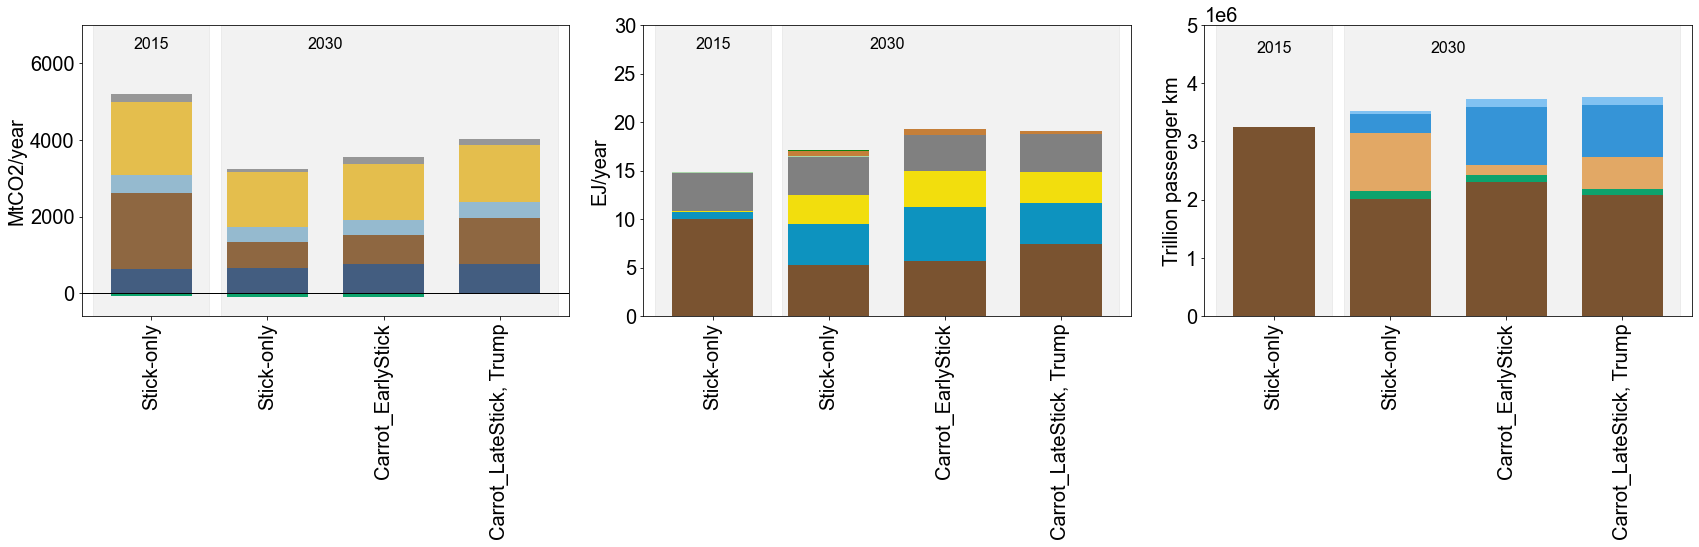

In [139]:
# now do ao version with 2 panels
# 设置整个图的字体为Arial
matplotlib.rcParams['font.family'] = 'Arial'
# 设置图中的所有文字字号为14
plt.rcParams['font.size'] = 20
# fig, axs = plt.subplots(2, 3, figsize=(20, 6), sharey=True)
fig, axs = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'width_ratios': [2, 2, 2]})

# r15.plot(kind='bar', stacked=True, ax=axs[0], cmap=GEN_HL, width=0.7)
all_df_secem.plot(kind='bar', stacked=True,  ax = axs[0], cmap=Huilin4, width=0.7)
all_df_power.plot(kind='bar', stacked=True, ax=axs[1], cmap=GEN_HL, width=0.7)
all_df_trn.plot(kind='bar', stacked=True, ax=axs[2], cmap=GEN_HL3, width=0.7)

ax0=axs[0]
ax1=axs[1]
ax2=axs[2]

ax0.set_ylim(-600, 7000)
ax1.set_ylim(0, 30)
ax2.set_ylim(0, 5000000)


axs[0].text(0, 6500, '2015', fontsize=16, ha='center', va='center', color='black')
axs[0].text(1.5, 6500, '2030', fontsize=16, ha='center', va='center', color='black')

axs[1].text(0, 28, '2015', fontsize=16, ha='center', va='center', color='black')
axs[1].text(1.5, 28, '2030', fontsize=16, ha='center', va='center', color='black')


axs[2].text(0, 4600000, '2015', fontsize=16, ha='center', va='center', color='black')
axs[2].text(1.5, 4600000, '2030', fontsize=16, ha='center', va='center', color='black')


# 去除legend
for ax in axs.flat:
    ax.legend().remove()
    ax.set_xlabel('')
    ax.axhline(y=0, color='black', linewidth=1)
# 设置 y 轴标签
axs[0].set_ylabel('MtCO2/year')
axs[1].set_ylabel('EJ/year')
axs[2].set_ylabel('Trillion passenger km')

ax0.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
ax0.axvspan(0.6, 3.5, color='gray', alpha=0.1)  
ax1.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
ax1.axvspan(0.6, 3.5, color='gray', alpha=0.1) 
ax2.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
ax2.axvspan(0.6, 3.5, color='gray', alpha=0.1) 
    
# 仅在第三个 panel 添加图例，并设置位置为右边
# axs[-1].legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=False,prop={'family': 'Arial', 'size': 14},ncol=1)
print("20240821-works")
# 调整布局
plt.tight_layout()

# plt.savefig("RR1v2Figure4_main_202502.svg", transparent = True)

# 显示图形
plt.show()

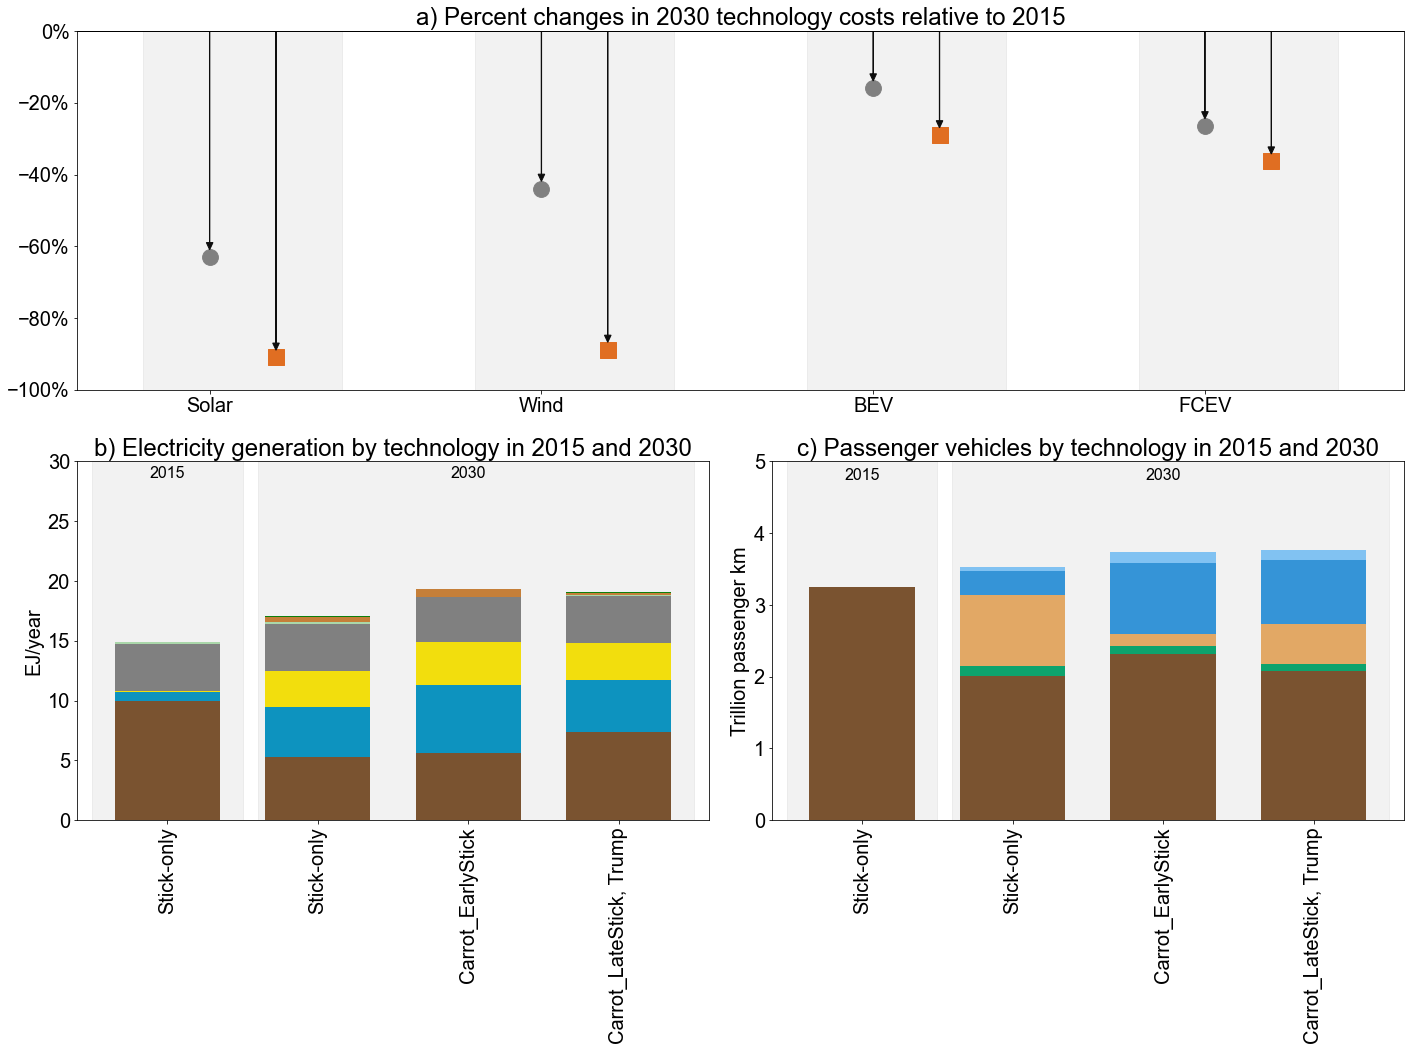

In [141]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick 

# 创建图形
fig = plt.figure(figsize=(20, 15))  

# 定义网格布局
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

# 第一行的全宽子图
ax0 = fig.add_subplot(gs[0, :])  

# 第二行的两个子图
ax1 = fig.add_subplot(gs[1, 0]) 
ax2 = fig.add_subplot(gs[1, 1]) 

# 设置 Y 轴范围
ax1.set_ylim(0, 30)
ax2.set_ylim(0, 5)

# X 轴坐标
x = [0.9, 1.9, 2.9, 3.9]
y = [1.1, 2.1, 3.1, 4.1]

# 确保数据是一维的
y1 = f4_change.values.flatten()
y2 = f4_change_subsidy.values.flatten()

# 画图
ax0.scatter(x, y1, marker='o', s=250, color = "grey", label='Default cost')
ax0.scatter(y, y2, marker='s', s=250, color = "#EC6D18", label='Subsidized cost')
# 画箭头：从 (x, 0) 指向 (x, y)
for i in range(len(x)):  
    ax0.arrow(x[i], 0, 0, y1[i]+0.04, head_width=0.02, head_length=0.02, fc='k', ec='k')

for i in range(len(y)):  
    ax0.arrow(y[i], 0, 0, y2[i]+0.04, head_width=0.02, head_length=0.02, fc='k', ec='k')  # 用红色标识

# 设置 X 轴标签
ax0.set_xticks(x)  
ax0.set_xticklabels(["Solar", "Wind", "BEV", "FCEV"])

# 设置标签和标题
ax0.set_ylim(-1,0)
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # 把 y 轴转成百分比
ax0.set_xlim(0.5, 4.5)
# ax0.set_xlabel('Technology')
# ax0.set_ylabel('Change')


# 画柱状图
all_df_trn2 = all_df_trn.div(1000000)
all_df_power.plot(kind='bar', stacked=True, ax=ax1, cmap=GEN_HL, width=0.7)
all_df_trn2.plot(kind='bar', stacked=True, ax=ax2, cmap=GEN_HL3, width=0.7)

# 添加文本（调整位置）

ax1.text(0, 29, '2015', fontsize=16, ha='center', va='center', color='black')
ax1.text(2, 29, '2030', fontsize=16, ha='center', va='center', color='black')

ax2.text(0, 4.8, '2015', fontsize=16, ha='center', va='center', color='black')
ax2.text(2,4.8, '2030', fontsize=16, ha='center', va='center', color='black')

# 移除 legend 并调整格式
for ax in [ax0, ax1, ax2]:  
    ax.legend().remove()
    ax.set_xlabel('')
    ax.axhline(y=0, color='black', linewidth=1)
#     ax.set_xticks() 

# 设置 Y 轴标签
ax1.set_ylabel('EJ/year')
ax2.set_ylabel('Trillion passenger km')

# 添加阴影区域
# **(5) 添加阴影**
highlight_regions = [1, 2, 3, 4]  # x 轴上的范围
for i in highlight_regions:
    ax0.axvspan(i-0.3, i + 0.3, color='gray', alpha=0.1)

ax1.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
ax1.axvspan(0.6, 3.5, color='gray', alpha=0.1) 
ax2.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
ax2.axvspan(0.6, 3.5, color='gray', alpha=0.1) 

ax0.set_title('a) Percent changes in 2030 technology costs relative to 2015')
ax1.set_title('b) Electricity generation by technology in 2015 and 2030')
ax2.set_title('c) Passenger vehicles by technology in 2015 and 2030')

# 调整布局
plt.tight_layout()
plt.savefig("RR1v2_figure4.svg", transparent = True)

# 显示图形
plt.show()


In [79]:
# now we need figure 4.
#panel 1 - tech cost changes

In [31]:
#figure 4 panel 2~4: innovation effects in 2050
#panel 2

In [32]:
# now let's do panel last - CO2 sequestration by tech
colors_pr = [#'#3cb44b',green for land use
    'green',
    'orange',
    '#6a4a3a',
    'grey'
          ]

# 创建自定义 colormap 对象
primary_cm = ListedColormap(colors_pr, name='my_colormap')
p_s = pd.read_excel("CO2_seq_202502_80p.xlsx", sheet_name='stick').iloc[:, :20]
p_2030nl = pd.read_excel("CO2_seq_202502_80p.xlsx", sheet_name='crt2030_nl').iloc[:, :20]
p_2030l = pd.read_excel("CO2_seq_202502_80p.xlsx", sheet_name='crt2030_l').iloc[:, :20]
p_2040nl = pd.read_excel("CO2_seq_202502_80p.xlsx", sheet_name='crt2040_nl').iloc[:, :20]
p_2040l = pd.read_excel("CO2_seq_202502_80p.xlsx", sheet_name='crt2040_l').iloc[:, :20]

# p_2030nl_trump = pd.read_excel("CO2_seq_0821_80p_trump.xlsx", sheet_name='2030nl_trump').iloc[:, :20]
# p_2030l_trump = pd.read_excel("CO2_seq_0821_80p_trump.xlsx", sheet_name='2030l_trump').iloc[:, :20]
p_2040nl_trump = pd.read_excel("CO2_seq_202502_80p.xlsx", sheet_name='2040nl_trump').iloc[:, :20]
# p_2040l_trump = pd.read_excel("CO2_seq_0821_80p_trump.xlsx", sheet_name='2040l_trump').iloc[:, :20]

all_p=[p_s, p_2030nl, p_2030l, p_2040nl,
#         p_2030nl_trump, p_2030l_trump, 
       p_2040nl_trump
      ]

def ccs(df):
    all_p = df['technology'].unique()
    all_p_ff = df[(df['technology'].str.contains("coal")) |(df['technology'].str.contains("gas")) |
                 (df['technology'].str.contains("refined")) 
                 ]
    all_p_ff['type'] = 'Fossil CCS'
    all_p_cement = df[df['technology'].str.contains("cement")
                 ]
    all_p_cement['type'] = 'Others'
    all_p_bio = df[(df['technology'].str.contains("biomass")) |(df['technology'].str.contains("biofuels")) |
                 (df['technology'].str.contains("paper"))  |(df['technology'].str.contains("ethanol"))
                 ]
    all_p_bio['type'] = 'BECCS'
    all_p_dac = df[df['technology'].str.contains("DAC")
                 ]
    all_p_dac['type'] = 'DAC'
    # 合并数据
    all_df_pp = pd.concat([all_p_ff, all_p_cement, all_p_bio, all_p_dac])

    # 选择特定列
    all_df_pp2 = all_df_pp[['scenario', 'type', 'i2025', 'i2030', 'i2035', 'i2040', 'i2045', 'i2050']]

    # print(all_df_pp2)
    sum_by_type = all_df_pp2.groupby('type').sum()
    dfsss=sum_by_type.transpose()
    return(dfsss)

np_s=ccs(p_s)
np_2030nl = ccs(p_2030nl)
np_2030l = ccs(p_2030l)
np_2040nl = ccs(p_2040nl)
np_2040l = ccs(p_2040l)
# np_2030nl_trump = ccs(p_2030nl_trump)
# np_2030l_trump = ccs(p_2030l_trump)
np_2040nl_trump = ccs(p_2040nl_trump)
# np_2040l_trump = ccs(p_2040l_trump)

np_s['scenario']='stick'
np_2030nl['scenario'] = '2030nl'
np_2030l['scenario'] ='2030l'
np_2040nl['scenario']='2040nl'

# np_2030nl_trump['scenario'] = '2030nl_trump'
# np_2030l_trump['scenario'] ='2030l_trump'
np_2040nl_trump['scenario']='2040nl_trump'

all_ccs1 = pd.concat([np_s, np_2030nl, np_2030l,np_2040nl, 
#                      np_2030nl_trump, 
                      np_2040nl_trump#, np_2030l_trump
                     ])
all_ccs1

all_ccs3 = all_ccs1[all_ccs1.index == 'i2050'] 

all_ccs3 = all_ccs3.reset_index(drop=True)

all_ccs3 = all_ccs3.set_index('scenario')  
all_ccs3


C:\Users\Huilin\AppData\Local\Temp\ipykernel_26452\2650355664.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_p_ff['type'] = 'Fossil CCS'
C:\Users\Huilin\AppData\Local\Temp\ipykernel_26452\2650355664.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_p_cement['type'] = 'Others'
C:\Users\Huilin\AppData\Local\Temp\ipykernel_26452\2650355664.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead



type,BECCS,DAC,Fossil CCS,Others
scenario,,,,
stick,234.274195,49.708683,255.426926,8.538469
2030nl,272.356875,76.791298,271.051183,8.117691
2030l,151.661927,308.502013,337.975630,7.574311
2040nl,466.839628,251.645168,328.322858,4.676405
2040nl_trump,687.994238,464.243169,354.529524,4.778377


In [33]:
all_ccs3=all_ccs3[all_ccs3.index.isin
                                  (['stick', '2030nl', "2030l",'2040nl',
                                                    '2040nl_trump'
                                                    ])]

In [34]:
all_ccs3

type,BECCS,DAC,Fossil CCS,Others
scenario,,,,
stick,234.274195,49.708683,255.426926,8.538469
2030nl,272.356875,76.791298,271.051183,8.117691
2030l,151.661927,308.502013,337.975630,7.574311
2040nl,466.839628,251.645168,328.322858,4.676405
2040nl_trump,687.994238,464.243169,354.529524,4.778377


In [35]:
trn_all_2050_t2 = trn_all_2050_t2[trn_all_2050_t2.index.isin
                                  (['Stick-only', 'Carrot_EarlyStick', "Carrot_EarlyStick_Innovation",
                                                   'Carrot_LateStick', 'Carrot_LateStick, Trump'                                   
                                                    ])]
trn_all_2050_t2

input,Fossil,Bioliquids,Hybrid Liquids,BEV,FCEV
scenario,,,,,
Stick-only,670225.155986,6.280449e+05,1.241983e+06,1.261871e+06,331615.61751
Carrot_EarlyStick,597923.920943,7.086842e+05,1.168378e+06,1.322803e+06,345418.40000
Carrot_EarlyStick_Innovation,456921.632357,2.725109e+05,6.024131e+05,6.084125e+06,334763.81550
Carrot_LateStick,359441.298100,1.003288e+06,7.957686e+05,1.592577e+06,394051.27880
"Carrot_LateStick, Trump",177673.647918,1.180015e+06,7.934187e+05,1.610428e+06,387116.02780


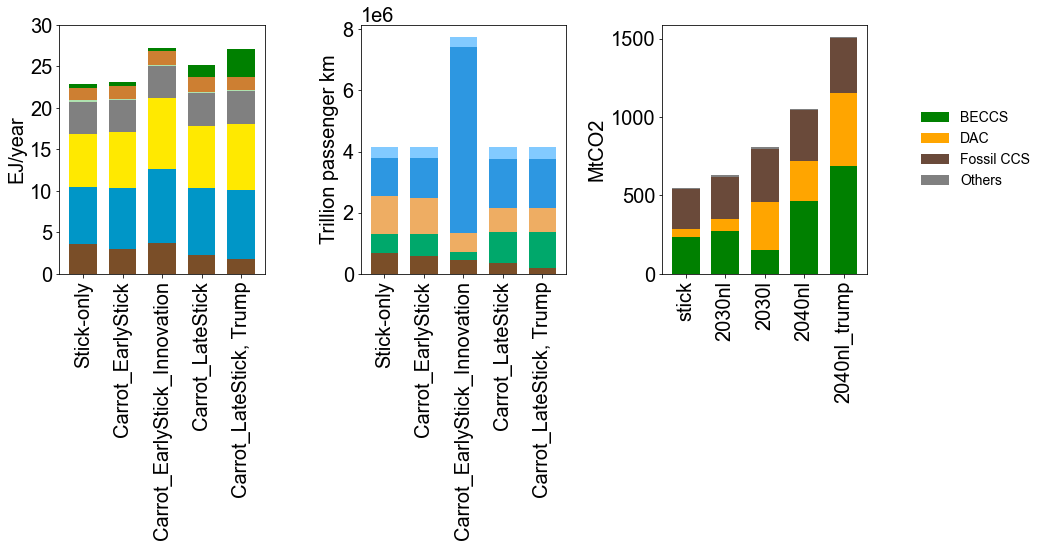

In [36]:
# now 3 panels

# order_r50 = ["category1", "category2", "category3"]  # 这里替换成你的实际类别
order_trn_all_2050_t2 = ['Stick-only', 'Carrot_EarlyStick', "Carrot_EarlyStick_Innovation",'Carrot_LateStick',
                                                    'Carrot_LateStick, Trump']
order_all_ccs3 = ['stick', '2030nl', "2030l",'2040nl','2040nl_trump']

# 重新设置分类索引的顺序
# r50.index = pd.Categorical(r50.index, categories=order_r50, ordered=True)
trn_all_2050_t2.index = pd.Categorical(trn_all_2050_t2.index, categories=order_trn_all_2050_t2, ordered=True)
all_ccs3.index = pd.Categorical(all_ccs3.index, categories=order_all_ccs3, ordered=True)

# 重新排序
# r50 = r50.sort_index()
trn_all_2050_t2 = trn_all_2050_t2.sort_index()
all_ccs3 = all_ccs3.sort_index()


# 设置整个图的字体为Arial
matplotlib.rcParams['font.family'] = 'Arial'
# 设置图中的所有文字字号为14
plt.rcParams['font.size'] = 20
# fig, axs = plt.subplots(2, 3, figsize=(20, 6), sharey=True)
fig, axs = plt.subplots(1, 3, figsize=(15, 8), gridspec_kw={'width_ratios': [1, 1, 1]})

# r15.plot(kind='bar', stacked=True, ax=axs[0], cmap=GEN_HL, width=0.7)
# all_df_secem.plot(kind='bar', stacked=True,  ax = axs[0], cmap=Huilin4, width=0.7)
r50.plot(kind='bar', stacked=True, ax=axs[0], cmap=GEN_HL, width=0.7)
trn_all_2050_t2.plot(kind='bar', stacked=True, ax=axs[1], cmap=GEN_HL3, width=0.7)
all_ccs3.plot(kind='bar', stacked=True, ax=axs[2],cmap=primary_cm, width=0.7)

ax0=axs[0]
ax1=axs[1]
ax2=axs[2]

ax0.set_ylim(0, 30)
# ax1.set_ylim(0, 25)
# ax2.set_ylim(0, 4500000)




# 去除legend
for ax in axs.flat:
    ax.legend().remove()
    ax.set_xlabel('')
    ax.axhline(y=0, color='black', linewidth=1)
# # # 设置 y 轴标签
axs[0].set_ylabel('EJ/year')
axs[1].set_ylabel('Trillion passenger km')
axs[2].set_ylabel('MtCO2')

# # ax0.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
# # ax0.axvspan(0.6, 2.5, color='gray', alpha=0.1)  
# # ax1.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
# # ax1.axvspan(0.6, 2.5, color='gray', alpha=0.1) 
# # ax2.axvspan(-0.5, 0.5, color='gray', alpha=0.1)  
# # ax2.axvspan(0.6, 2.5, color='gray', alpha=0.1) 
    
# 仅在第三个 panel 添加图例，并设置位置为右边
axs[-1].legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=False,prop={'family': 'Arial', 'size': 14},ncol=1)

# 调整布局
plt.tight_layout()

# plt.savefig("Figure5_202502_main.svg", transparent = True)

# 显示图形
plt.show()

In [37]:
# dot_trn_dot2

In [38]:
# # new figure 4 - calculating solar cost part
# # USE THIS 20240516
# Solar_CC2050= 156
# Solar_CC2015 = 567
# Solar_CCL2050 = 125
# Solar_CC_NL = (Solar_CC2050-Solar_CC2015)/Solar_CC2015
# Solar_CC_L = (Solar_CCL2050-Solar_CC2015)/Solar_CC2015

In [39]:
#RR1v2 figure 5:

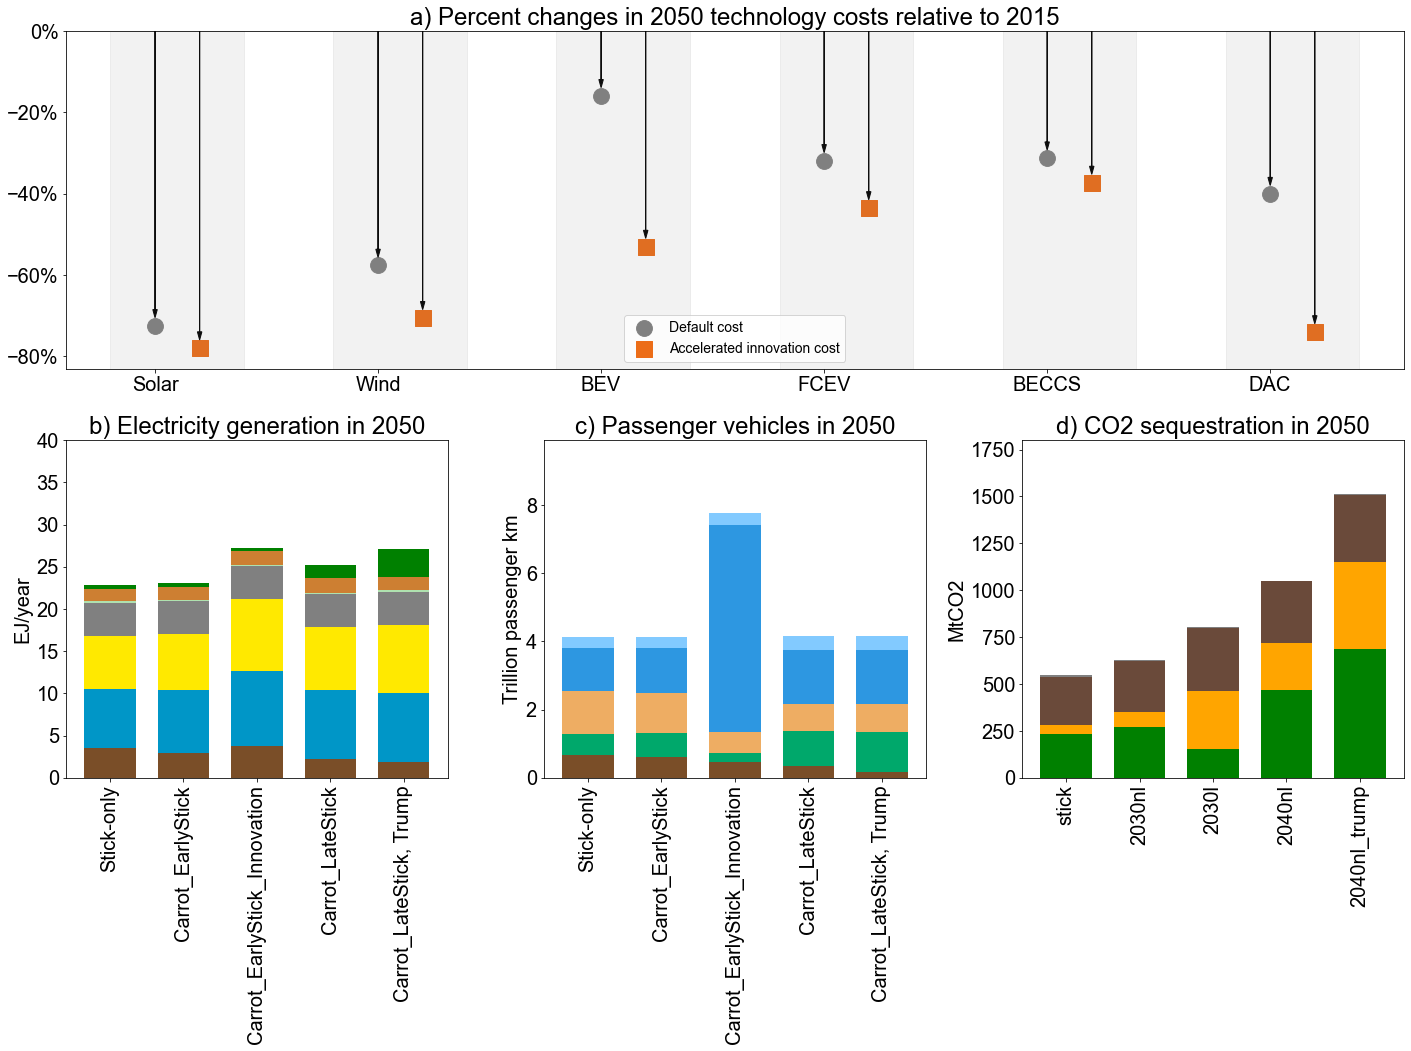

In [82]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 创建图形
fig = plt.figure(figsize=(20, 15))  

# 定义网格布局
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1,1])

# 第一行的全宽子图
ax0 = fig.add_subplot(gs[0, :])  

# 第二行的两个子图
ax1 = fig.add_subplot(gs[1, 0]) 
ax2 = fig.add_subplot(gs[1, 1]) 
ax3 = fig.add_subplot(gs[1, 2]) 

# 设置 Y 轴范围
# ax1.set_ylim(0, 30)
# ax2.set_ylim(0, 5000000)

# X 轴坐标
a = [0.9, 1.9, 2.9, 3.9,4.9,5.9]
b = [1.1, 2.1, 3.1, 4.1,5.1,6.1]

# 确保数据是一维的
b1 = f5_change.values.flatten()
b2 = f5_change_subsidy.values.flatten()

# 画图
ax0.scatter(a, b1, marker='o', s=250, color = "grey", label='Default cost')
ax0.scatter(b, b2, marker='s', s=250, color = "#EC6D18", label='Accelerated innovation cost')
# 画箭头：从 (x, 0) 指向 (x, y)
for i in range(len(a)):  
    ax0.arrow(a[i], 0, 0, b1[i]+0.04, head_width=0.02, head_length=0.02, fc='k', ec='k')

for i in range(len(b)):  
    ax0.arrow(b[i], 0, 0, b2[i]+0.04, head_width=0.02, head_length=0.02, fc='k', ec='k')  

# 设置 X 轴标签
ax0.set_xticks(a)  
ax0.set_xticklabels(["Solar", "Wind", "BEV", "FCEV","BECCS","DAC"])

# 设置标签和标题

ax0.set_xlim(0.5, 6.5)
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))  # 把 y 轴转成百分比

# ax0.set_xlabel('Technology')
# ax0.set_ylabel('Change')


# plotting
#make trn as trillion passenger km
trn_all_2050_t3 = trn_all_2050_t2.div(1000000)
r50.plot(kind='bar', stacked=True, ax=ax1, cmap=GEN_HL, width=0.7)
trn_all_2050_t3.plot(kind='bar', stacked=True, ax=ax2, cmap=GEN_HL3, width=0.7)
all_ccs3.plot(kind='bar', stacked=True, ax=ax3,cmap=primary_cm, width=0.7)



# 添加文本（调整位置）

# ax1.text(0, 29, '2015', fontsize=16, ha='center', va='center', color='black')
# ax1.text(2.5, 29, '2030', fontsize=16, ha='center', va='center', color='black')

# ax2.text(0, 4800000, '2015', fontsize=16, ha='center', va='center', color='black')
# ax2.text(2.5,4800000, '2030', fontsize=16, ha='center', va='center', color='black')

# 移除 legend 并调整格式
for ax in [ ax1, ax2, ax3]:  
    ax.legend().remove()
    ax.set_xlabel('')
    ax.axhline(y=0, color='black', linewidth=1)
#     ax.set_xticks() 

# # # 设置 y 轴标签
ax1.set_ylabel('EJ/year')
ax2.set_ylabel('Trillion passenger km')
ax3.set_ylabel('MtCO2')

# 设置 Y 轴标签
ax1.set_ylabel('EJ/year')
ax2.set_ylabel('Trillion passenger km')

# 添加阴影区域
# **(5) 添加阴影**
highlight_regions = [1, 2, 3, 4,5,6]  # x 轴上的范围
for i in highlight_regions:
    ax0.axvspan(i-0.3, i + 0.3, color='gray', alpha=0.1)

ax0.set_ylim(-0.83, 0)
ax1.set_ylim(0, 40)
ax2.set_ylim(0, 9.9)
ax3.set_ylim(0, 1800)

ax0.set_title('a) Percent changes in 2050 technology costs relative to 2015')
ax1.set_title('b) Electricity generation in 2050')
ax2.set_title('c) Passenger vehicles in 2050')
ax3.set_title('d) CO2 sequestration in 2050')

ax0.legend(loc='best', fontsize=14) #'upper left'

# 调整布局
plt.tight_layout()
plt.savefig("RR1v2_figure5.svg")


# 显示图形
plt.show()
